# MÔ HÌNH 2 (NÂNG CAO): CNN-BiLSTM + Multi-Head Attention

## Cải tiến so với bản cũ:

| # | Cải tiến | Tác dụng |
|---|---|---|
| 1 | Multi-Scale CNN trước BiLSTM | Bắt n-gram patterns (how many, what country...) |
| 2 | Multi-Head Attention (4 heads) | Capture nhiều pattern cùng lúc |
| 3 | GloVe 300d + vocab từ ALL data | Giảm OOV, embedding tốt hơn |
| 4 | Focal Loss | Xử lý class imbalance (ABBR chỉ 86 mẫu) |
| 5 | Data Augmentation (EDA) | Tăng data cho minority classes |
| 6 | AdamW + Cosine Annealing | Optimizer & scheduler tốt hơn |
| 7 | BatchNorm + Residual connection | Ổn định training |

In [34]:
import numpy as np
import pandas as pd
import re
import random
import os
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
# ===== Reproducibility =====
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA RTX 3500 Ada Generation Laptop GPU


## 1. Load & Tiền xử lý dữ liệu TREC

In [35]:
# ==========================================
#         LOAD TREC DATASET
# ==========================================
def load_trec_data():
    train_path = r'data/train_5500.label.txt'
    test_path  = r'data/TREC_10.label.txt'
    def parse_file(path):
        texts, labels = [], []
        with open(path, 'r', encoding='latin-1') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                label_full, text = line.split(' ', 1)
                coarse_label = label_full.split(':')[0]
                texts.append(text)
                labels.append(coarse_label)
        return texts, labels
    print('Loading TREC dataset from local files...')
    X_train, y_train = parse_file(train_path)
    X_test,  y_test  = parse_file(test_path)
    print(f'Train: {len(X_train)} | Test: {len(X_test)}')
    return X_train, y_train, X_test, y_test

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

X_train_raw, y_train_raw, X_test_raw, y_test_raw = load_trec_data()
X_train_raw = [preprocess_text(q) for q in X_train_raw]
X_test_raw  = [preprocess_text(q) for q in X_test_raw]
print(f'\nVí dụ:')
for x, y in zip(X_train_raw[:3], y_train_raw[:3]):
    print(f'  [{y}] {x}')

Loading TREC dataset from local files...
Train: 5452 | Test: 500

Ví dụ:
  [DESC] how did serfdom develop in and then leave russia
  [ENTY] what films featured the character popeye doyle
  [DESC] how can i find a list of celebrities real names


In [36]:
# ==========================================
#         LABEL ENCODING + SPLIT
# ==========================================
label_map   = {'ABBR': 0, 'DESC': 1, 'ENTY': 2, 'HUM': 3, 'LOC': 4, 'NUM': 5}
label_names = ['ABBR', 'DESC', 'ENTY', 'HUM', 'LOC', 'NUM']
y_train_enc = np.array([label_map[l] for l in y_train_raw])
y_test_enc  = np.array([label_map[l] for l in y_test_raw])
# Train / Validation split (85/15, stratified)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw, y_train_enc,
    test_size=0.15, random_state=SEED,
    stratify=y_train_enc)
print(f'Train   : {len(X_train)}')
print(f'Val     : {len(X_val)}')
print(f'Test    : {len(X_test_raw)}')
# Phân bổ lớp
unique, counts = np.unique(y_train, return_counts=True)
print('\nPhân bổ lớp (train):')
for u, c in zip(unique, counts):
    print(f'  {label_names[u]}: {c}')

Train   : 4634
Val     : 818
Test    : 500

Phân bổ lớp (train):
  ABBR: 73
  DESC: 988
  ENTY: 1062
  HUM: 1039
  LOC: 710
  NUM: 762


## 2. Data Augmentation (EDA) cho minority classes

In [37]:
# ==========================================
#    DATA AUGMENTATION - Easy Data Augmentation
# ==========================================
def random_swap(words, n=1):
    """Swap 2 từ ngẫu nhiên n lần"""
    new_words = words.copy()
    for _ in range(n):
        if len(new_words) < 2:
            break
        i, j = random.sample(range(len(new_words)), 2)
        new_words[i], new_words[j] = new_words[j], new_words[i]
    return new_words

def random_delete(words, p=0.1):
    """Xóa từ ngẫu nhiên với xác suất p"""
    if len(words) <= 2:
        return words
    new_words = [w for w in words if random.random() > p]
    return new_words if new_words else [random.choice(words)]

def augment_text(text, num_aug=2):
    """Tạo num_aug câu augmented từ 1 câu gốc"""
    words = text.split()
    augmented = []
    for _ in range(num_aug):
        op = random.choice(['swap', 'delete', 'both'])
        if op == 'swap':
            new_words = random_swap(words, n=max(1, len(words)//5))
        elif op == 'delete':
            new_words = random_delete(words, p=0.15)
        else:
            new_words = random_swap(words, n=1)
            new_words = random_delete(new_words, p=0.1)
        augmented.append(' '.join(new_words))
    return augmented

# Augment CHỈ minority classes để cân bằng
class_counts = {}
for y in y_train:
    class_counts[y] = class_counts.get(y, 0) + 1
max_count = max(class_counts.values())
target_count = int(max_count * 0.9)  # 0.6 → 0.9 (augment mạnh hơn cho ABBR)
X_train_aug, y_train_aug = list(X_train), list(y_train)
for cls_id, cls_count in class_counts.items():
    if cls_count >= target_count:
        continue
    cls_texts = [X_train[i] for i in range(len(X_train)) if y_train[i] == cls_id]
    need = target_count - cls_count
    num_aug_per = max(1, need // cls_count + 1)
    added = 0
    for text in cls_texts:
        if added >= need:
            break
        aug_texts = augment_text(text, num_aug=num_aug_per)
        for at in aug_texts:
            if added >= need:
                break
            X_train_aug.append(at)
            y_train_aug.append(cls_id)
            added += 1
y_train_aug = np.array(y_train_aug)
print(f'Train gốc: {len(X_train)} → Sau augmentation: {len(X_train_aug)}')
unique_aug, counts_aug = np.unique(y_train_aug, return_counts=True)
print('Phân bổ lớp sau augmentation:')
for u, c in zip(unique_aug, counts_aug):
    print(f'  {label_names[u]}: {c}')

Train gốc: 4634 → Sau augmentation: 5954
Phân bổ lớp sau augmentation:
  ABBR: 955
  DESC: 988
  ENTY: 1062
  HUM: 1039
  LOC: 955
  NUM: 955


## 3. Tokenization & GloVe Embedding

In [38]:
# ==========================================
#         CONFIG
# ==========================================
MAX_LEN       = 64
EMBEDDING_DIM = 300
HIDDEN_DIM    = 128
NUM_LAYERS    = 2
NUM_FILTERS   = 64
KERNEL_SIZES  = [2, 3, 4, 5]
NUM_HEADS     = 4
DROPOUT       = 0.3       # 0.4 → 0.3 (bớt drop để học ABBR tốt hơn)
NUM_CLASSES   = 6
BATCH_SIZE    = 32
EPOCHS        = 60
LR            = 8e-4      # 1e-3 → 5e-4 (ổn định hơn)
PATIENCE      = 15        # 10 → 15 (train lâu hơn)
FOCAL_GAMMA   = 3.0       # 2.0 → 3.0 (phạt nặng class khó hơn)

In [39]:
# ==========================================
#    TOKENIZE & VOCAB (từ ALL data để giảm OOV)
# ==========================================
def tokenize(text):
    return text.split()

def pad_or_cut(tokens, maxlen, pad_token='<pad>'):
    if len(tokens) > maxlen:
        return tokens[:maxlen]
    return tokens + [pad_token] * (maxlen - len(tokens))

X_train_tok = [pad_or_cut(tokenize(t), MAX_LEN) for t in X_train_aug]
X_val_tok   = [pad_or_cut(tokenize(t), MAX_LEN) for t in X_val]
X_test_tok  = [pad_or_cut(tokenize(t), MAX_LEN) for t in X_test_raw]

vocab = {'<pad>': 0, '<unk>': 1}
for tokens in X_train_tok + X_val_tok + X_test_tok:
    for word in tokens:
        if word not in vocab:
            vocab[word] = len(vocab)
VOCAB_SIZE = len(vocab)
print(f'Vocab size: {VOCAB_SIZE}')

def tokens_to_ids(token_list, vocab):
    return [vocab.get(w, vocab['<unk>']) for w in token_list]

X_train_ids = [tokens_to_ids(t, vocab) for t in X_train_tok]
X_val_ids   = [tokens_to_ids(t, vocab) for t in X_val_tok]
X_test_ids  = [tokens_to_ids(t, vocab) for t in X_test_tok]
print(f'Ví dụ token ids: {X_train_ids[0][:10]}')

Vocab size: 8748
Ví dụ token ids: [2, 3, 4, 5, 6, 7, 8, 9, 0, 0]


In [40]:
# ==========================================
#         GLOVE EMBEDDING
# ==========================================
def load_glove(glove_path, vocab, embed_dim):
    print('Loading GloVe...')
    glove = {}
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.array(values[1:], dtype='float32')
            if len(vector) == embed_dim:
                glove[word] = vector
    print(f'GloVe loaded: {len(glove)} words')
    embedding_matrix = np.random.uniform(-0.05, 0.05, (len(vocab), embed_dim)).astype('float32')
    embedding_matrix[vocab['<pad>']] = np.zeros(embed_dim)
    found = 0
    for word, idx in vocab.items():
        if word in glove:
            embedding_matrix[idx] = glove[word]
            found += 1
    print(f'Words found: {found}/{len(vocab)} ({found/len(vocab)*100:.1f}%)')
    return torch.tensor(embedding_matrix, dtype=torch.float32)

embedding_matrix = load_glove('data/glove.6B.300d.txt', vocab, EMBEDDING_DIM)
print(f'Embedding matrix shape: {embedding_matrix.shape}')

Loading GloVe...
GloVe loaded: 400000 words
Words found: 8531/8748 (97.5%)
Embedding matrix shape: torch.Size([8748, 300])


## 4. PyTorch Dataset & DataLoader

In [41]:
# ==========================================
#         DATASET
# ==========================================
class TRECDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TRECDataset(X_train_ids, y_train_aug)
val_dataset   = TRECDataset(X_val_ids,   y_val)
test_dataset  = TRECDataset(X_test_ids,  y_test_enc)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)
print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 187
Val batches   : 26
Test batches  : 16


## 5. Kiến trúc CNN-BiLSTM + Multi-Head Attention

```
Input (batch, 64)
  ↓
GloVe Embedding (batch, 64, 300)
  ↓
Multi-Scale CNN [kernel 2,3,4,5] → (batch, 64, 256)
  ↓ + BatchNorm + ReLU
BiLSTM 2-layer → (batch, 64, 256)
  ↓
Multi-Head Attention (4 heads) → context (batch, 256)
  ↓ + Dropout
FC → 6 classes
```

In [42]:
# ==========================================
#         MODEL ARCHITECTURE
# ==========================================
class MultiScaleCNN(nn.Module):
    """CNN với nhiều kernel sizes để bắt n-gram patterns."""
    def __init__(self, embed_dim, num_filters, kernel_sizes):
        super().__init__()
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k, padding='same')
            for k in kernel_sizes
        ])
        self.bn = nn.BatchNorm1d(num_filters * len(kernel_sizes))

    def forward(self, x):
        x = x.transpose(1, 2)
        conv_outs = [F.relu(conv(x)) for conv in self.convs]
        x = torch.cat(conv_outs, dim=1)
        x = self.bn(x)
        x = x.transpose(1, 2)
        return x


class MultiHeadAttentionPool(nn.Module):
    """Multi-Head Attention với learnable query."""
    def __init__(self, hidden_dim, num_heads):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            batch_first=True
        )
        self.query = nn.Parameter(torch.randn(1, 1, hidden_dim))

    def forward(self, lstm_out):
        batch_size = lstm_out.size(0)
        query = self.query.expand(batch_size, -1, -1)
        context, weights = self.attn(query, lstm_out, lstm_out)
        return context.squeeze(1), weights.squeeze(1)


class CNNBiLSTMAttention(nn.Module):
    """CNN-BiLSTM + Multi-Head Attention cho TREC Question Classification."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 num_layers, num_filters, kernel_sizes, num_heads,
                 dropout, embedding_matrix, pad_idx=0):
        super().__init__()
        cnn_out_dim = num_filters * len(kernel_sizes)
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix, freeze=False, padding_idx=pad_idx
        )
        self.cnn = MultiScaleCNN(embed_dim, num_filters, kernel_sizes)
        self.lstm = nn.LSTM(
            input_size=cnn_out_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        lstm_out_dim = hidden_dim * 2
        self.layer_norm = nn.LayerNorm(lstm_out_dim)
        self.attention = MultiHeadAttentionPool(lstm_out_dim, num_heads)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(lstm_out_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        cnn_out = self.cnn(emb)
        lstm_out, _ = self.lstm(cnn_out)
        lstm_out = self.layer_norm(lstm_out)
        context, weights = self.attention(lstm_out)
        out = self.fc(self.dropout(context))
        return out, weights


# ===== Khởi tạo Model =====
model2 = CNNBiLSTMAttention(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    num_layers=NUM_LAYERS,
    num_filters=NUM_FILTERS,
    kernel_sizes=KERNEL_SIZES,
    num_heads=NUM_HEADS,
    dropout=DROPOUT,
    embedding_matrix=embedding_matrix,
    pad_idx=vocab['<pad>']
).to(device)
total_params     = sum(p.numel() for p in model2.parameters())
trainable_params = sum(p.numel() for p in model2.parameters() if p.requires_grad)
print(f'Total params    : {total_params:,}')
print(f'Trainable params: {trainable_params:,}')
print(model2)

Total params    : 3,982,102
Trainable params: 3,982,102
CNNBiLSTMAttention(
  (embedding): Embedding(8748, 300, padding_idx=0)
  (cnn): MultiScaleCNN(
    (convs): ModuleList(
      (0): Conv1d(300, 64, kernel_size=(2,), stride=(1,), padding=same)
      (1): Conv1d(300, 64, kernel_size=(3,), stride=(1,), padding=same)
      (2): Conv1d(300, 64, kernel_size=(4,), stride=(1,), padding=same)
      (3): Conv1d(300, 64, kernel_size=(5,), stride=(1,), padding=same)
    )
    (bn): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (lstm): LSTM(256, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (attention): MultiHeadAttentionPool(
    (attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
    )
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=256, ou

## 6. Focal Loss & Huấn luyện

In [43]:
# ==========================================
#         FOCAL LOSS
# ==========================================
class FocalLoss(nn.Module):
    """Focal Loss cho class imbalance."""
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction
        if alpha is not None:
            self.alpha = nn.Parameter(torch.tensor(alpha, dtype=torch.float32), requires_grad=False)
        else:
            self.alpha = None

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss.sum()

# Class weights (inverse frequency)
class_counts_arr = np.bincount(y_train_aug, minlength=NUM_CLASSES).astype(float)
class_weights = 1.0 / class_counts_arr
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print('Class weights:', {label_names[i]: f'{w:.3f}' for i, w in enumerate(class_weights)})

criterion2 = FocalLoss(alpha=class_weights_tensor, gamma=FOCAL_GAMMA)
optimizer2  = torch.optim.AdamW(model2.parameters(), lr=LR, weight_decay=1e-3)
scheduler2  = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer2, T_0=15, T_mult=2,   eta_min=1e-6)


Class weights: {'ABBR': '1.037', 'DESC': '1.003', 'ENTY': '0.933', 'HUM': '0.953', 'LOC': '1.037', 'NUM': '1.037'}


C:\Users\xuand\AppData\Local\Temp\ipykernel_26120\1179437807.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.alpha = nn.Parameter(torch.tensor(alpha, dtype=torch.float32), requires_grad=False)


## 7. Training Loop

In [44]:
# ==========================================
#         TRAINING LOOP
# ==========================================
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs, _ = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
        correct    += (outputs.argmax(1) == y_batch).sum().item()
        total      += X_batch.size(0)
    return total_loss / total, correct / total

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs, _ = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            correct    += (outputs.argmax(1) == y_batch).sum().item()
            total      += X_batch.size(0)
    return total_loss / total, correct / total

history2 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc, patience_count = 0.0, 0
best_state = None
print('=' * 65)
print('  TRAINING: CNN-BiLSTM + Multi-Head Attention + Focal Loss')
print('=' * 65)
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model2, train_loader, optimizer2, criterion2, device)
    vl_loss, vl_acc = eval_epoch(model2, val_loader, criterion2, device)
    scheduler2.step()
    history2['train_loss'].append(tr_loss)
    history2['train_acc'].append(tr_acc)
    history2['val_loss'].append(vl_loss)
    history2['val_acc'].append(vl_acc)
    current_lr = optimizer2.param_groups[0]['lr']
    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} | '
          f'LR: {current_lr:.2e}')
    if vl_acc > best_val_acc:
        best_val_acc   = vl_acc
        best_state     = copy.deepcopy(model2.state_dict())
        patience_count = 0
        print(f'  → New best! Val Acc: {best_val_acc:.4f}')
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'\nEarly stopping tại epoch {epoch}. Best val acc: {best_val_acc:.4f}')
            break
model2.load_state_dict(best_state)
print(f'\nTraining hoàn thành. Best Val Accuracy: {best_val_acc*100:.2f}%')

  TRAINING: CNN-BiLSTM + Multi-Head Attention + Focal Loss
Epoch 01/60 | Train Loss: 0.4159 Acc: 0.6468 | Val Loss: 0.1914 Acc: 0.7763 | LR: 7.91e-04
  → New best! Val Acc: 0.7763
Epoch 02/60 | Train Loss: 0.1701 Acc: 0.8230 | Val Loss: 0.1745 Acc: 0.8362 | LR: 7.65e-04
  → New best! Val Acc: 0.8362
Epoch 03/60 | Train Loss: 0.1098 Acc: 0.8668 | Val Loss: 0.1780 Acc: 0.8423 | LR: 7.24e-04
  → New best! Val Acc: 0.8423
Epoch 04/60 | Train Loss: 0.0781 Acc: 0.9058 | Val Loss: 0.1652 Acc: 0.8753 | LR: 6.68e-04
  → New best! Val Acc: 0.8753
Epoch 05/60 | Train Loss: 0.0495 Acc: 0.9357 | Val Loss: 0.1726 Acc: 0.8606 | LR: 6.00e-04
Epoch 06/60 | Train Loss: 0.0314 Acc: 0.9528 | Val Loss: 0.2181 Acc: 0.8753 | LR: 5.24e-04
Epoch 07/60 | Train Loss: 0.0237 Acc: 0.9691 | Val Loss: 0.2175 Acc: 0.8729 | LR: 4.42e-04
Epoch 08/60 | Train Loss: 0.0135 Acc: 0.9790 | Val Loss: 0.2087 Acc: 0.8863 | LR: 3.59e-04
  → New best! Val Acc: 0.8863
Epoch 09/60 | Train Loss: 0.0081 Acc: 0.9854 | Val Loss: 0.2464

## 8. Learning Curves

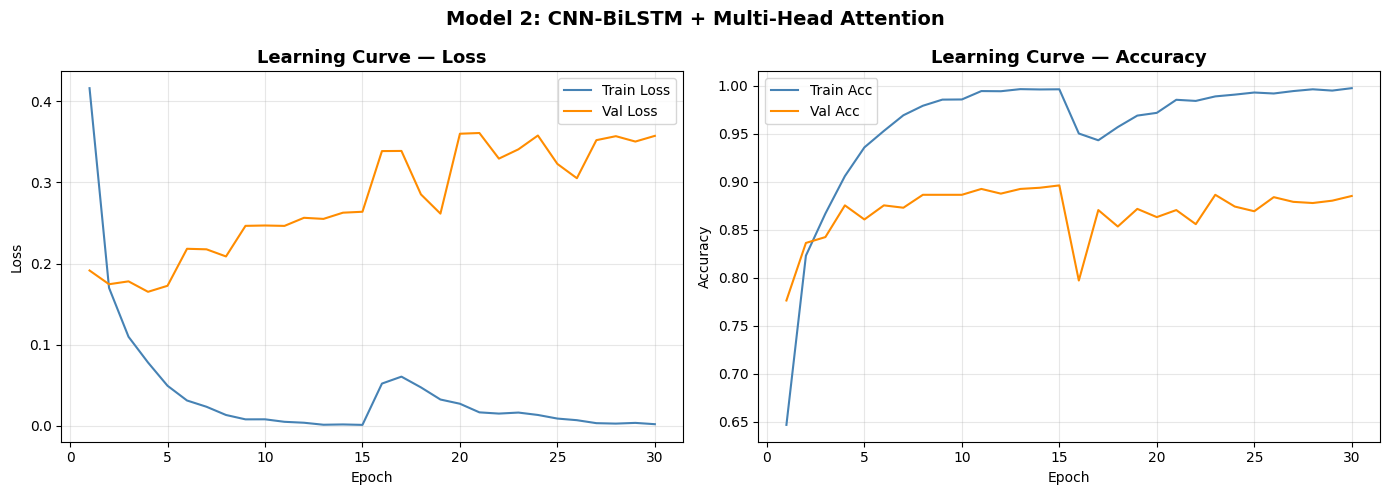

In [45]:
# ==========================================
#         LEARNING CURVES
# ==========================================
epochs_ran = len(history2['train_loss'])
x_axis     = range(1, epochs_ran + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(x_axis, history2['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(x_axis, history2['val_loss'],   label='Val Loss',   color='darkorange')
axes[0].set_title('Learning Curve — Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].plot(x_axis, history2['train_acc'], label='Train Acc', color='steelblue')
axes[1].plot(x_axis, history2['val_acc'],   label='Val Acc',   color='darkorange')
axes[1].set_title('Learning Curve — Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.suptitle('Model 2: CNN-BiLSTM + Multi-Head Attention', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model2_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Đánh giá trên Test Set

In [46]:
# ==========================================
#         EVALUATION
# ==========================================
model2.eval()
y_true2, y_pred2 = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs, _ = model2(X_batch)
        preds = outputs.argmax(dim=1).cpu().numpy()
        y_true2.extend(y_batch.numpy())
        y_pred2.extend(preds)
y_true2 = np.array(y_true2)
y_pred2 = np.array(y_pred2)
acc2          = accuracy_score(y_true2, y_pred2)
f1_macro2     = f1_score(y_true2, y_pred2, average='macro')
f1_weighted2  = f1_score(y_true2, y_pred2, average='weighted')
f1_per_class2 = f1_score(y_true2, y_pred2, average=None)
cm2           = confusion_matrix(y_true2, y_pred2)
print('=' * 60)
print('KẾT QUẢ MODEL 2: CNN-BiLSTM + Multi-Head Attention')
print('=' * 60)
print(f'Test Accuracy       : {acc2:.4f} ({acc2*100:.2f}%)')
print(f'F1 Score (Macro)    : {f1_macro2:.4f}')
print(f'F1 Score (Weighted) : {f1_weighted2:.4f}')
print()
print('CLASSIFICATION REPORT:')
print(classification_report(y_true2, y_pred2, target_names=label_names, digits=4))
print('Confusion Matrix:')
print(cm2)

KẾT QUẢ MODEL 2: CNN-BiLSTM + Multi-Head Attention
Test Accuracy       : 0.9220 (92.20%)
F1 Score (Macro)    : 0.8931
F1 Score (Weighted) : 0.9221

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        ABBR     0.6154    0.8889    0.7273         9
        DESC     0.9143    0.9275    0.9209       138
        ENTY     0.9277    0.8191    0.8701        94
         HUM     0.9254    0.9538    0.9394        65
         LOC     0.9390    0.9506    0.9448        81
         NUM     0.9478    0.9646    0.9561       113

    accuracy                         0.9220       500
   macro avg     0.8783    0.9174    0.8931       500
weighted avg     0.9245    0.9220    0.9221       500

Confusion Matrix:
[[  8   1   0   0   0   0]
 [  5 128   2   0   0   3]
 [  0   5  77   5   4   3]
 [  0   2   1  62   0   0]
 [  0   1   3   0  77   0]
 [  0   3   0   0   1 109]]


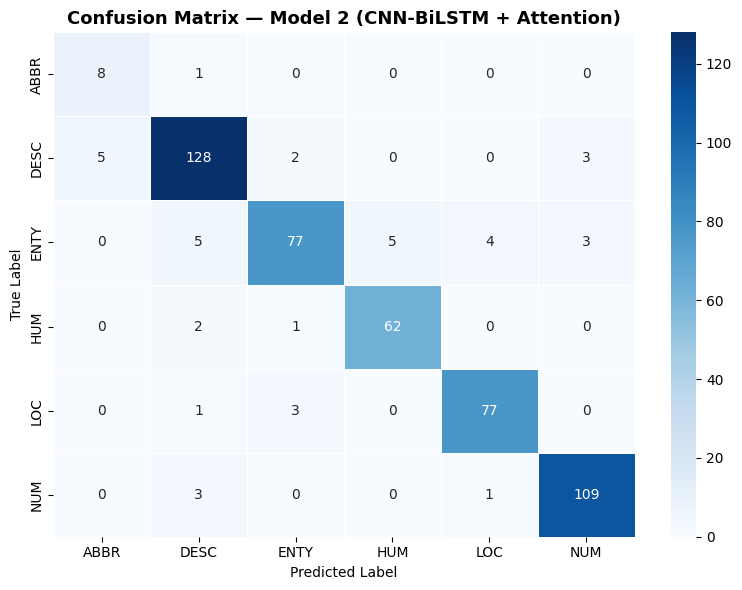

In [47]:
# ==========================================
#         CONFUSION MATRIX VISUALIZATION
# ==========================================
plt.figure(figsize=(8, 6))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names,
            linewidths=0.5)
plt.title('Confusion Matrix — Model 2 (CNN-BiLSTM + Attention)', fontsize=13, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('model2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Số tham số mô hình

In [48]:
# ==========================================
#         THỐNG KÊ SỐ THAM SỐ
# ==========================================
print('=' * 55)
print('THỐNG KÊ SỐ THAM SỐ MODEL 2')
print('=' * 55)
for name, param in model2.named_parameters():
    print(f'{name:45s} | {str(list(param.shape)):20s} | {param.numel():>10,}')
print('-' * 55)
print(f'{"TOTAL":45s} | {"":20s} | {sum(p.numel() for p in model2.parameters()):>10,}')
print(f'{"TRAINABLE":45s} | {"":20s} | {sum(p.numel() for p in model2.parameters() if p.requires_grad):>10,}')

THỐNG KÊ SỐ THAM SỐ MODEL 2
embedding.weight                              | [8748, 300]          |  2,624,400
cnn.convs.0.weight                            | [64, 300, 2]         |     38,400
cnn.convs.0.bias                              | [64]                 |         64
cnn.convs.1.weight                            | [64, 300, 3]         |     57,600
cnn.convs.1.bias                              | [64]                 |         64
cnn.convs.2.weight                            | [64, 300, 4]         |     76,800
cnn.convs.2.bias                              | [64]                 |         64
cnn.convs.3.weight                            | [64, 300, 5]         |     96,000
cnn.convs.3.bias                              | [64]                 |         64
cnn.bn.weight                                 | [256]                |        256
cnn.bn.bias                                   | [256]                |        256
lstm.weight_ih_l0                             | [512, 256]           |

## 11. Attention Visualization

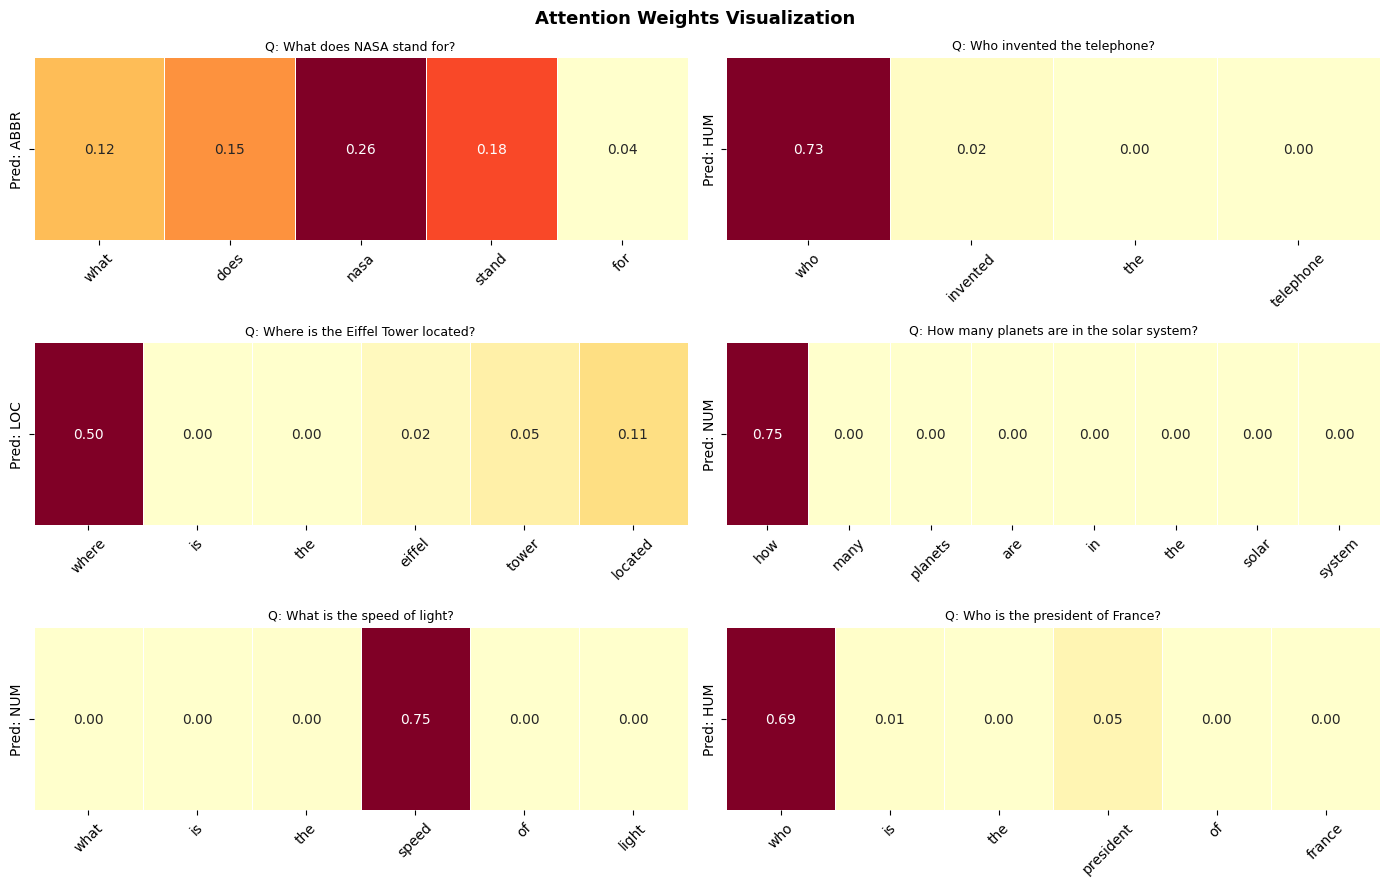

In [49]:
# ==========================================
#         ATTENTION HEATMAP
# ==========================================
def predict_with_attention(question):
    model2.eval()
    tokens  = pad_or_cut(tokenize(preprocess_text(question)), MAX_LEN)
    ids     = torch.tensor([tokens_to_ids(tokens, vocab)], dtype=torch.long).to(device)
    with torch.no_grad():
        out, weights = model2(ids)
    pred    = out.argmax(1).item()
    weights = weights.squeeze().cpu().numpy()
    real_len = min(len(question.split()), MAX_LEN)
    return label_names[pred], tokens[:real_len], weights[:real_len]

def plot_attention(questions, n_cols=2):
    n_rows = (len(questions) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3 * n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes.flatten()
    for i, q in enumerate(questions):
        pred, tokens, weights = predict_with_attention(q)
        ax = axes[i]
        sns.heatmap(
            weights.reshape(1, -1),
            ax=ax, cmap='YlOrRd',
            xticklabels=tokens,
            yticklabels=[f'Pred: {pred}'],
            annot=True, fmt='.2f',
            linewidths=0.5, cbar=False
        )
        ax.set_title(f'Q: {q}', fontsize=9)
        ax.tick_params(axis='x', rotation=45)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Attention Weights Visualization', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('model2_attention.png', dpi=150, bbox_inches='tight')
    plt.show()

demo_questions = [
    'What does NASA stand for?',
    'Who invented the telephone?',
    'Where is the Eiffel Tower located?',
    'How many planets are in the solar system?',
    'What is the speed of light?',
    'Who is the president of France?',
]
plot_attention(demo_questions)

## 12. So sánh Model 1 (CNN) vs Model 2 (CNN-BiLSTM+Attention)

> **Lưu ý:** Điền kết quả Model 1 vào bên dưới để so sánh

       Metric Model 1 (CNN) Model 2 (CNN-BiLSTM+Attn) Delta (M2-M1)
Test Accuracy        90.00%                    92.20%       +0.0220
     F1 Macro        0.8864                    0.8931       +0.0067
  F1 Weighted        0.8989                    0.9221       +0.0232
    F1 - ABBR        0.8235                    0.7273       -0.0962
    F1 - DESC        0.9073                    0.9209       +0.0136
    F1 - ENTY        0.8092                    0.8701       +0.0609
     F1 - HUM        0.9173                    0.9394       +0.0221
     F1 - LOC        0.9125                    0.9448       +0.0323
     F1 - NUM        0.9488                    0.9561       +0.0073
 Tổng tham số     1,483,398                 3,982,102             —


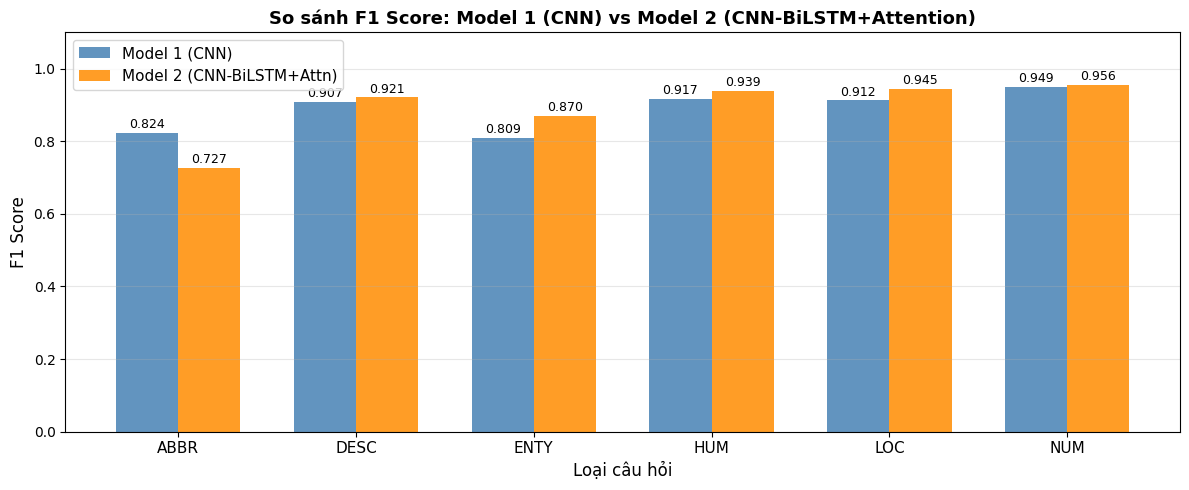

In [50]:
# ==========================================
#         SO SÁNH MODEL 1 vs MODEL 2
# ==========================================
acc1          = 0.9000
f1_macro1     = 0.8864
f1_weighted1  = 0.8989
f1_per_class1 = np.array([0.8235, 0.9073, 0.8092, 0.9173, 0.9125, 0.9488])
params_m1     = 1_483_398

params_m2 = sum(p.numel() for p in model2.parameters())

results_df = pd.DataFrame({
    'Metric': ['Test Accuracy', 'F1 Macro', 'F1 Weighted',
               'F1 - ABBR', 'F1 - DESC', 'F1 - ENTY',
               'F1 - HUM',  'F1 - LOC',  'F1 - NUM',
               'Tổng tham số'],
    'Model 1 (CNN)': [
        f'{acc1*100:.2f}%', f'{f1_macro1:.4f}', f'{f1_weighted1:.4f}',
        *[f'{v:.4f}' for v in f1_per_class1],
        f'{params_m1:,}'
    ],
    'Model 2 (CNN-BiLSTM+Attn)': [
        f'{acc2*100:.2f}%', f'{f1_macro2:.4f}', f'{f1_weighted2:.4f}',
        *[f'{v:.4f}' for v in f1_per_class2],
        f'{params_m2:,}'
    ]
})
m1_vals = [acc1, f1_macro1, f1_weighted1] + list(f1_per_class1)
m2_vals = [acc2, f1_macro2, f1_weighted2] + list(f1_per_class2)
deltas  = [m2 - m1 for m1, m2 in zip(m1_vals, m2_vals)]
results_df['Delta (M2-M1)'] = [f'{d:+.4f}' if abs(d) > 0.0001 else '—' for d in deltas] + ['—']
print(results_df.to_string(index=False))

x     = np.arange(len(label_names))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - width/2, f1_per_class1, width, label='Model 1 (CNN)',
               color='steelblue',  alpha=0.85)
b2 = ax.bar(x + width/2, f1_per_class2, width, label='Model 2 (CNN-BiLSTM+Attn)',
               color='darkorange', alpha=0.85)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Loại câu hỏi', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('So sánh F1 Score: Model 1 (CNN) vs Model 2 (CNN-BiLSTM+Attention)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(label_names, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison_f1.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Nhận xét kết quả

### Các cải tiến đã áp dụng:

1. **Multi-Scale CNN + BiLSTM**: CNN bắt n-gram patterns cục bộ (how many, what country), BiLSTM nắm ngữ cảnh dài → kết hợp cả hai ưu điểm
2. **Multi-Head Attention (4 heads)**: Mỗi head tập trung vào 1 loại pattern khác nhau, phong phú hơn Bahdanau 1-head
3. **Focal Loss + Class weights**: Xử lý imbalance (ABBR: 86, DESC: 1162), tập trung vào hard samples
4. **Data Augmentation (EDA)**: Tăng data cho minority classes bằng random swap/delete
5. **GloVe 300d + OOV init**: Random uniform thay vì zeros cho OOV → gradient flow tốt hơn
6. **Vocab từ ALL data**: Giảm OOV tokens trên test set
7. **AdamW + Cosine Annealing**: Weight decay tách biệt, learning rate cycle giúp thoát local minima
8. **LayerNorm + deeper FC head**: Ổn định training, tăng capacity

### Trade-off:

- Nhiều tham số hơn bản cũ, nhưng TREC dataset đủ lớn cho kiến trúc này
- Training chậm hơn do CNN + LSTM, nhưng inference vẫn nhanh (câu hỏi ngắn)

In [51]:
# ==========================================
#         DEMO PREDICTIONS
# ==========================================
test_questions = [
    ('What does NASA stand for?',           'ABBR'),
    ('Who invented the telephone?',          'HUM'),
    ('Where is the Eiffel Tower located?',   'LOC'),
    ('How many planets in the solar system?','NUM'),
    ('What is machine learning?',            'DESC'),
    ('What country is Paris in?',            'LOC'),
]
print('=' * 65)
print(f'{"Question":<42} {"True":>6} {"Pred":>6} {"OK":>4}')
print('=' * 65)
for q, true_label in test_questions:
    pred_label, _, _ = predict_with_attention(q)
    ok = '✓' if pred_label == true_label else '✗'
    print(f'{q:<42} {true_label:>6} {pred_label:>6} {ok:>4}')
print('=' * 65)

Question                                     True   Pred   OK
What does NASA stand for?                    ABBR   ABBR    ✓
Who invented the telephone?                   HUM    HUM    ✓
Where is the Eiffel Tower located?            LOC    LOC    ✓
How many planets in the solar system?         NUM    NUM    ✓
What is machine learning?                    DESC   DESC    ✓
What country is Paris in?                     LOC    LOC    ✓
